<a href="https://colab.research.google.com/github/guanyuq03/econ5200-causal-project/blob/main/5200_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 5200: Consulting Report — Final Project

**From Model to Recommendation**

This notebook scaffolds the full consulting report pipeline: executive summary, identification strategy, causal analysis, threats assessment, Streamlit export, presentation script, and AI methodology appendix.

---

## Part 0: Setup

In [ ]:
!pip install econml -q

In [ ]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict

# Causal ML (uncomment the one you use)
from econml.dml import LinearDML, CausalForestDML
# from doubleml import DoubleMLPLR, DoubleMLData

# Stats
from scipy import stats
import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
## Part 1: Executive Summary

Use SCR (Situation – Complication – Resolution) structure. Fill this in LAST, after your analysis is complete.

> **We estimate that [treatment] has an effect of [X] on [outcome] (95% CI: [a, b]).**
>
> **Situation:** ___
> **Complication:** ___
> **Resolution:** ___
>
> **We recommend [action] because [reason].**
>
> **Key assumption that could invalidate this:** ___

---
## Part 2: Data + Identification Strategy

### Research Design

- **Research question:** Does participation in a job training program cause higher post-program earnings?
- **Identification strategy:** Double Machine Learning (DML)
- **Key assumption:** Conditional on observed covariates, treatment assignment is independent of potential outcomes.
- **Treatment variable:** treat (program participation)
- **Outcome variable:** re78 (post-program earnings in 1978)
- **Controls:** age, educ, black, hispan, married, nodegree, re74, re75
- **Why prediction alone is insufficient:** A prediction model can identify who is associated with higher earnings, but it cannot answer the causal question of whether the training program itself raises earnings. Because program participation is not random, a purely predictive model would mix the effect of treatment with pre-existing differences across individuals.

In [ ]:
# --- Data Loading ---
df = sm.datasets.get_rdataset("lalonde", "MatchIt").data
df.head()

,treat,age,educ,race,married,nodegree,re74,re75,re78
rownames,,,,,,,,,
NSW1,1,37,11,black,1,1,0.0,0.0,9930.0460
NSW2,1,22,9,hispan,0,1,0.0,0.0,3595.8940
NSW3,1,30,12,black,0,0,0.0,0.0,24909.4500
NSW4,1,27,11,black,0,1,0.0,0.0,7506.1460
NSW5,1,33,8,black,0,1,0.0,0.0,289.7899


Although the dataset contains fewer than 1,000 observations, it is a widely used benchmark dataset in causal inference and is appropriate for studying treatment effect estimation and selection bias.

In [ ]:
# --- EDA: Summary Statistics ---
df.describe()

,treat,age,educ,married,nodegree,re74,re75,re78
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.301303,27.363192,10.268730,0.415309,0.630293,4557.546569,2184.938207,6792.834483
std,0.459198,9.881187,2.628325,0.493177,0.483119,6477.964479,3295.679043,7470.730792
min,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.000000,9.000000,0.000000,0.000000,0.000000,0.000000,238.283425
50%,0.000000,25.000000,11.000000,0.000000,1.000000,1042.330000,601.548400,4759.018500
75%,1.000000,32.000000,12.000000,1.000000,1.000000,7888.498250,3248.987500,10893.592500
max,1.000000,55.000000,18.000000,1.000000,1.000000,35040.070000,25142.240000,60307.930000


In [ ]:
# --- EDA: Missing Data ---
df.isnull().sum().sort_values(ascending=False).head(10)

,0
treat,0
age,0
educ,0
race,0
married,0
nodegree,0
re74,0
re75,0
re78,0


No missing values are observed in the dataset, so missing data is unlikely to be a major source of bias.

In [ ]:
# --- EDA: Balance Check (treated vs. untreated) ---
df['black'] = (df['race'] == 'black').astype(int)
df['hispan'] = (df['race'] == 'hispan').astype(int)
balance_vars = ['age', 'educ', 'married', 'nodegree', 're74', 're75', 're78', 'black', 'hispan']
df.groupby('treat')[balance_vars].mean().T

treat,0,1
age,28.030303,25.816216
educ,10.235431,10.345946
married,0.512821,0.189189
nodegree,0.596737,0.708108
re74,5619.236506,2095.573689
re75,2466.484443,1532.055314
re78,6984.169742,6349.143530
black,0.202797,0.843243
hispan,0.142191,0.059459


The balance check shows meaningful differences between treated and untreated individuals, especially in prior earnings. In particular, the treatment group appears more economically disadvantaged before the program, which suggests that treatment assignment is not random.

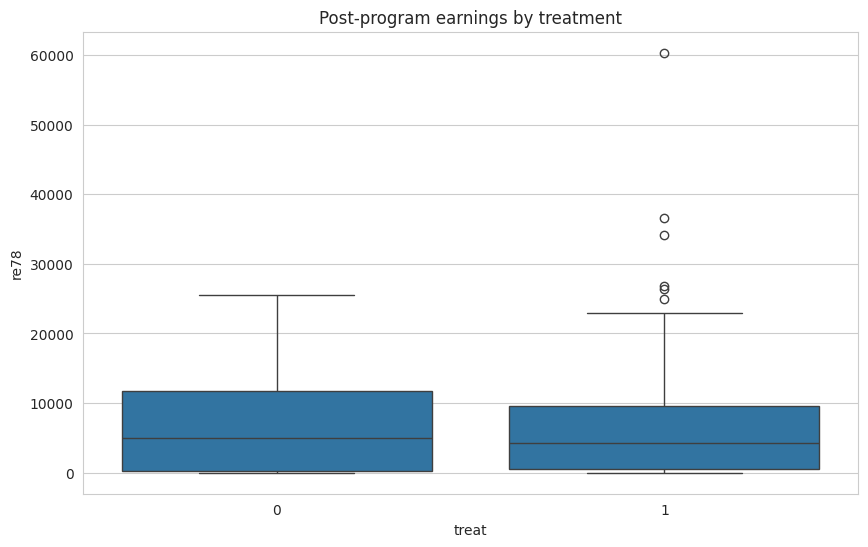

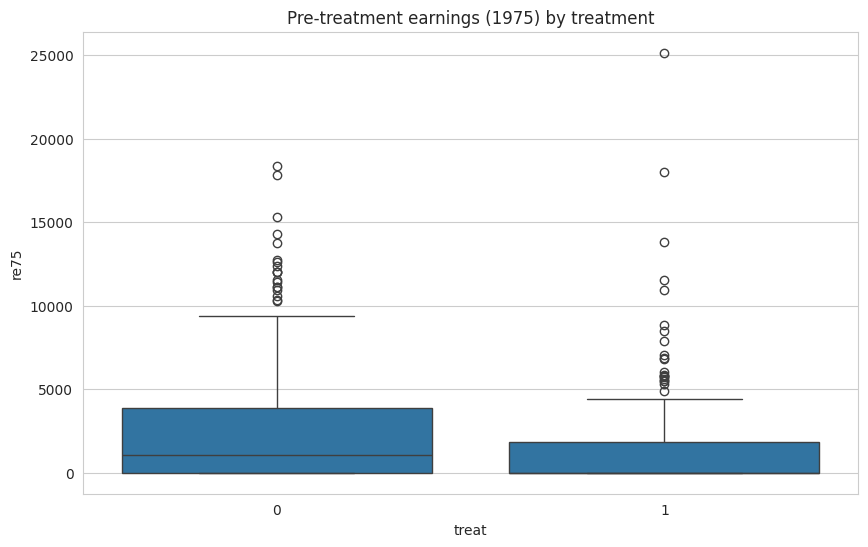

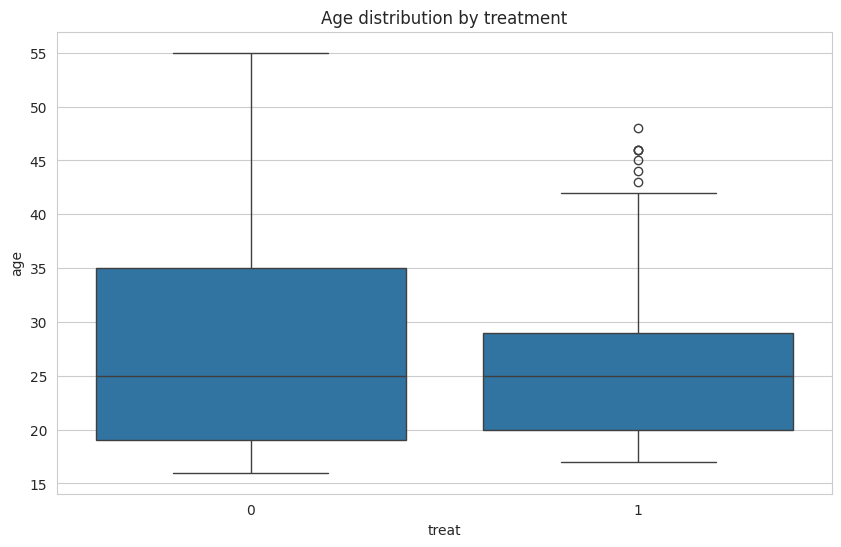

In [ ]:
# --- EDA: Treatment-Outcome Visualization ---
# Post-treatment earnings
sns.boxplot(data=df, x='treat', y='re78')
plt.title('Post-program earnings by treatment')
plt.show()

# Pre-treatment earnings (important!)
sns.boxplot(data=df, x='treat', y='re75')
plt.title('Pre-treatment earnings (1975) by treatment')
plt.show()

# Age
sns.boxplot(data=df, x='treat', y='age')
plt.title('Age distribution by treatment')
plt.show()

The visualizations provide clear evidence that treated and untreated individuals differ before the program begins. In particular, the distribution of pre-treatment earnings (re75) shows that individuals in the treatment group tend to have lower prior income compared to those in the control group. This suggests that participants in the job training program were more economically disadvantaged before receiving treatment.

The post-program earnings (re78) distributions show some overlap between treated and untreated groups, but do not immediately reveal a clear treatment effect. This highlights the limitation of relying on raw comparisons alone.

The age distribution appears relatively similar across groups, indicating that age is less likely to be a major source of imbalance compared to prior earnings.

Overall, these patterns confirm the presence of non-random selection into treatment and reinforce the need for a causal inference approach rather than a simple descriptive comparison.

---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

This simple comparison is expected to be biased. Document *why*.

In [ ]:
# --- Naive OLS ---
import statsmodels.formula.api as smf

# Naive OLS
naive_model = smf.ols('re78 ~ treat', data=df).fit()
print(naive_model.summary())

naive_estimate = naive_model.params['treat']
naive_ci = naive_model.conf_int().loc['treat'].values

print(f'\nNaive estimate: {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])')

                            OLS Regression Results                            
Dep. Variable:                   re78   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9338
Date:                Sat, 18 Apr 2026   Prob (F-statistic):              0.334
Time:                        03:33:43   Log-Likelihood:                -6346.4
No. Observations:                 614   AIC:                         1.270e+04
Df Residuals:                     612   BIC:                         1.271e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6984.1697    360.710     19.362      0.0

The naive OLS estimate suggests that participation in the job training program reduces earnings by approximately −635 dollars (95% CI: [−1925, 655]). The estimate is not statistically significant.

**Why the naive estimate is biased:** The naive estimate is biased because participation in the job training program is not randomly assigned. As shown in the balance checks and visualizations, individuals in the treatment group tend to have lower pre-treatment earnings and are more economically disadvantaged than those in the control group.

This means that a simple comparison of post-program earnings confounds the effect of the program with pre-existing differences across individuals. Because the treated group starts from a lower baseline, the naive estimate is downward biased, understating the true causal effect of the training program.

### 3b. Causal Estimate

In [ ]:
# --- Causal Method: Double Machine Learning (example) ---
from econml.dml import LinearDML

RANDOM_STATE = 42

Y = df['re78'].values
T = df['treat'].values

# controls（confounders）
W = df[['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']].values

# DML
dml = LinearDML(
    model_y=GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
    model_t=GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
    cv=5,
    random_state=RANDOM_STATE
)

dml.fit(Y, T, X=None, W=W)

causal_estimate = dml.ate(X=None)
causal_ci = dml.ate_interval(X=None, alpha=0.05)

print(f'Causal ATE: {causal_estimate:.4f}')
print(f'95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}]')

Causal ATE: 1244.8419
95% CI: [-373.3657, 2863.0496]


Using Double Machine Learning (DML), the estimated causal effect of participation in the job training program on post-program earnings is approximately 1244.84 dollars. The 95% confidence interval is [-373.37, 2863.05].

This estimate is substantially higher than the naive OLS estimate and suggests a positive effect of the training program. Although the confidence interval includes zero and the estimate is not statistically significant at the 5% level, the magnitude and direction of the estimate are consistent with the presence of selection bias in the naive comparison.

### 3c. Prediction Model (for comparison)

In [ ]:
# --- Predictive Model (NOT causal — for comparison only) ---
from sklearn.metrics import r2_score, mean_squared_error

features = ['treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
y_pred = cross_val_predict(rf, df[features], df['re78'], cv=5)

print(f'Prediction R²: {r2_score(df["re78"], y_pred):.3f}')
print(f'Prediction RMSE: {np.sqrt(mean_squared_error(df["re78"], y_pred)):.3f}')

print('\nNote: This tells us how well we can PREDICT the outcome,')
print('but NOT how the treatment CAUSES changes in the outcome.')

Prediction R²: 0.042
Prediction RMSE: 7306.271

Note: This tells us how well we can PREDICT the outcome,
but NOT how the treatment CAUSES changes in the outcome.


The predictive model achieves an R² of 0.042 and an RMSE of approximately 7306, indicating limited predictive power.

While the model can capture some variation in earnings, this result highlights an important distinction: predictive performance does not imply causal identification. A model can predict outcomes using variables correlated with treatment without isolating the causal effect of the treatment itself. Therefore, predictive models alone are insufficient for answering the causal question of whether the training program increases earnings.

### 3d. Compare Naive vs. Causal

> The naive estimate is [X], the causal estimate is [Y]. The difference of [Z] is attributable to [confounding/selection bias].

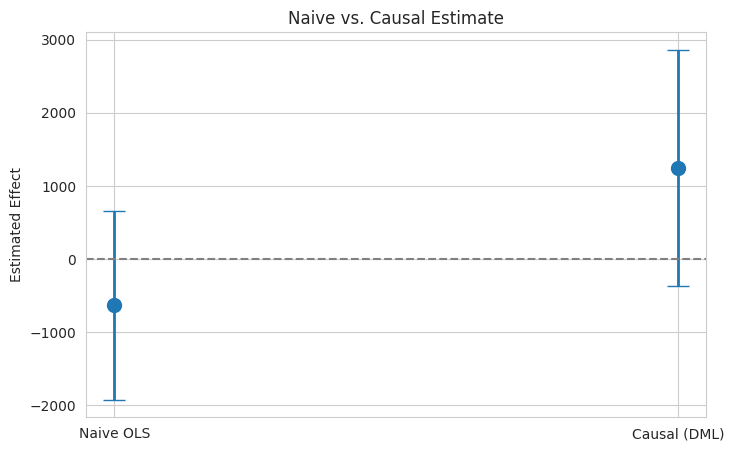

In [ ]:
# --- Comparison Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

estimates = ['Naive OLS', 'Causal (DML)']
points = [naive_estimate, causal_estimate]
ci_lower = [naive_ci[0], causal_ci[0]]
ci_upper = [naive_ci[1], causal_ci[1]]

errors = [[p - l for p, l in zip(points, ci_lower)],
          [u - p for p, u in zip(points, ci_upper)]]

ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=8,
            markersize=10, linewidth=2)

ax.axhline(y=0, color='gray', linestyle='--')
ax.set_ylabel('Estimated Effect')
ax.set_title('Naive vs. Causal Estimate')

plt.show()

The naive estimate is approximately −635, while the causal estimate is approximately 1245. The difference between these estimates is substantial and reflects the presence of selection bias.

In the naive comparison, individuals in the treatment group appear to earn less, which could suggest that the program is ineffective or even harmful. However, this conclusion is misleading because treated individuals are more economically disadvantaged prior to the program, as shown by their lower pre-treatment earnings.

After controlling for these pre-treatment differences using DML, the estimated effect becomes positive. This indicates that the naive estimate is downward biased, and that the training program likely has a positive impact on earnings that is masked by selection effects in the raw data.

### 3e. Robustness Check

In [ ]:
# --- Robustness: Different nuisance model ---
from sklearn.ensemble import RandomForestRegressor

dml_robust = LinearDML(
    model_y=RandomForestRegressor(n_estimators=200, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, random_state=42),
    cv=5,
    random_state=42
)

dml_robust.fit(Y, T, X=None, W=W)

robust_ate = dml_robust.ate(X=None)
robust_ci = dml_robust.ate_interval(X=None, alpha=0.05)

print(f'Robustness ATE: {robust_ate:.4f}')
print(f'95% CI: [{robust_ci[0]:.4f}, {robust_ci[1]:.4f}]')

Robustness ATE: 991.8634
95% CI: [-586.2821, 2570.0088]


As a robustness check, I re-estimate the causal effect using an alternative specification with Random Forest nuisance models. The resulting estimate is approximately 991.86, with a 95% confidence interval of [-586.28, 2570.01].

The robustness estimate remains positive and of similar magnitude to the main DML estimate. This consistency suggests that the estimated treatment effect is not driven by a specific modeling choice and increases confidence in the overall conclusion.

---
## Part 4: Threats to Identification

**Minimum 500 words. Be honest — this is where you demonstrate critical thinking.**

### 1. Most Serious Threat

- **Threat:** The most serious threat is unobserved selection into treatment. Even after controlling for observed characteristics such as age, education, race, marital status, and prior earnings, individuals who participate in the training program may differ in unobserved factors such as motivation, ability, or job search intensity.
- **Direction of bias:** This could bias the estimated treatment effect upward if more motivated individuals are more likely to participate and also more likely to earn higher income regardless of the program. However, earlier evidence suggests that treated individuals are more disadvantaged, so the naive estimate is downward biased. The direction of bias in the causal estimate remains ambiguous.
- **What would address it:** The ideal solution would be randomized assignment to treatment or a valid instrumental variable that affects participation but not earnings directly.

### 2. Second Threat

- **Threat:** Model misspecification in the DML approach.
- **Why it matters:** If the machine learning models used to estimate the nuisance functions (outcome and treatment models) are poorly specified, the resulting treatment effect estimates may still be biased.
- **Partial mitigation:** I use flexible machine learning models (Gradient Boosting and Random Forest) and perform a robustness check using alternative specifications, which produce similar results.

### 3. What I Cannot Rule Out

Despite using DML and controlling for observed confounders, I cannot fully rule out the presence of unobserved variables that influence both treatment assignment and earnings. Therefore, the estimated effect should be interpreted as a causal estimate under the assumption of no unobserved confounding, rather than a definitive causal effect.

---
## Part 5: Streamlit Dashboard Export

Copy the template below into a file called `app.py` in your project repo. Customize the what-if logic with your actual model.

**Deploy to Streamlit Community Cloud** and submit the permanent URL.

In [ ]:
# Save this as app.py in your project repo

streamlit_template = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="Consulting Report Dashboard", layout="wide")
st.title("Consulting Report: [Your Title]")

# --- Sidebar: What-If Controls ---
st.sidebar.header("What-If Scenarios")

treatment_multiplier = st.sidebar.slider(
    "Treatment intensity multiplier",
    min_value=0.5, max_value=3.0, value=1.0, step=0.1
)

# TODO: Add more sliders for your specific parameters
# control_level = st.sidebar.selectbox("Control scenario", ["Low", "Medium", "High"])

# --- Load your fitted model or pre-computed results ---
# Option 1: Load a pickled model
# import joblib
# model = joblib.load("fitted_model.pkl")

# Option 2: Use pre-computed coefficients
baseline_ate = 0.0    # TODO: Replace with your causal estimate
baseline_se = 0.0     # TODO: Replace with your standard error

# --- Compute What-If Estimate ---
adjusted_ate = baseline_ate * treatment_multiplier
adjusted_se = baseline_se * treatment_multiplier
ci_lower = adjusted_ate - 1.96 * adjusted_se
ci_upper = adjusted_ate + 1.96 * adjusted_se

# --- Display Results ---
col1, col2, col3 = st.columns(3)
col1.metric("Estimated Effect", f"{adjusted_ate:.3f}")
col2.metric("95% CI Lower", f"{ci_lower:.3f}")
col3.metric("95% CI Upper", f"{ci_upper:.3f}")

st.markdown(f"""
> **What-if interpretation:** If treatment intensity is multiplied by
> {treatment_multiplier:.1f}x, the estimated effect changes to
> {adjusted_ate:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]).
""")

# --- Uncertainty Visualization ---
multipliers = np.arange(0.5, 3.1, 0.1)
ates = baseline_ate * multipliers
ses = baseline_se * multipliers

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=multipliers, y=ates + 1.96 * ses,
    mode="lines", line=dict(width=0), showlegend=False
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates - 1.96 * ses,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(26,35,126,0.2)", name="95% CI"
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates,
    mode="lines", line=dict(color="#1a237e", width=2), name="Estimated Effect"
))
fig.add_vline(x=treatment_multiplier, line_dash="dash", line_color="red",
              annotation_text=f"Current: {treatment_multiplier:.1f}x")
fig.update_layout(
    title="What-If: Effect vs. Treatment Intensity",
    xaxis_title="Treatment Intensity Multiplier",
    yaxis_title="Estimated Causal Effect",
    template="plotly_white"
)
st.plotly_chart(fig, use_container_width=True)

# --- Counterfactual Scenario ---
st.subheader("Counterfactual: What if treatment intensity doubled?")
counterfactual_ate = baseline_ate * 2.0
counterfactual_ci = (counterfactual_ate - 1.96 * baseline_se * 2.0,
                     counterfactual_ate + 1.96 * baseline_se * 2.0)
st.write(f"If treatment intensity doubled, the estimated effect would be "
         f"**{counterfactual_ate:.3f}** (95% CI: [{counterfactual_ci[0]:.3f}, {counterfactual_ci[1]:.3f}]).")
'''

# Uncomment to write the template to disk:
with open('app.py', 'w') as f:
  f.write(streamlit_template)
print('app.py written. Deploy to Streamlit Community Cloud.')

print('Streamlit template ready. Uncomment the write block above to export.')

app.py written. Deploy to Streamlit Community Cloud.
Streamlit template ready. Uncomment the write block above to export.


---
## Part 6: Presentation Script

**5 minutes total. Practice with a timer.**

| Segment | Time | Your Script |
|---------|------|-------------|
| **Hook** | 30s | ___ |
| **Problem** | 60s | ___ |
| **Method** | 60s | ___ |
| **Finding** | 60s | ___ |
| **Recommendation** | 60s | ___ |
| **Defense** | 30s | ___ |

### Adversarial Prep

| Question Category | Your Prepared Answer |
|-------------------|---------------------|
| "How do you know this is causal?" | ___ |
| "Why this model?" | ___ |
| "Would this generalize?" | ___ |
| "Is the effect large enough?" | ___ |

---
## Part 7: AI Methodology Appendix (P.R.I.M.E.)

Document at least 3 significant AI interactions.

### Entry 1: [Task — e.g., Code Generation]

- Prompt: I asked the AI to generate Python code to implement a naive OLS regression and a Double Machine Learning (DML) model using the Lalonde dataset, including extracting coefficients and confidence intervals.
- Response: The AI provided a statsmodels OLS specification (re78 ~ treat) and EconML-based DML code using Gradient Boosting models, along with instructions for computing the average treatment effect and confidence intervals.
- Iterate: I clarified variable names (e.g., treat, re78) and adjusted the input structure to match my dataset format. I also asked follow-up questions when encountering errors related to missing columns and package installation.
- Modify: I adapted the code to include the correct control variables (age, educ, black, hispan, married, nodegree, re74, re75) and ensured proper preprocessing (e.g., creating dummy variables for race categories).
- Evaluate: I verified correctness by checking whether the regression outputs were consistent with expectations from the balance check and visualizations. In particular, I confirmed that the naive estimate was negative and the DML estimate became positive, which aligns with known selection bias in the Lalonde dataset.

### Entry 2: [Task — e.g., Analysis Assistance]

- Prompt: I asked the AI to help interpret the results of the naive OLS and DML estimates and to determine the direction of bias in the naive estimate.
- Response: The AI explained that treated individuals have lower pre-treatment earnings, which leads to a downward bias in the naive estimate. It also helped interpret the difference between the naive and causal estimates as evidence of selection bias.
- Iterate: I compared the AI’s explanation with my own results, especially the balance check and boxplots for pre-treatment earnings (re75), and asked for clarification on bias direction.
- Modify: I rewrote the explanation in my own words and aligned it with my specific outputs (e.g., naive estimate of −635 and DML estimate of approximately 1245).
- Evaluate: I confirmed the logic by ensuring consistency across all parts of the analysis: the treated group had lower prior earnings, the naive estimate was negative, and the causal estimate became positive after controlling for confounders.

### Entry 3: [Task — e.g., Writing / Literature Review]

- Prompt: I asked the AI to help draft sections of the report, including visualization interpretation, causal explanation, and the comparison between prediction and causal models.
- Response: The AI generated structured paragraphs explaining differences between treated and control groups, the role of selection bias, and why predictive models cannot answer causal questions.
- Iterate: I refined the wording to match my writing style and simplified language to improve clarity.
- Modify: I incorporated my actual results (e.g., coefficient values, confidence intervals, and model performance metrics) and adjusted the tone to be consistent with a professional consulting report.
- Evaluate: I ensured that all written explanations accurately reflect the data and model outputs in my notebook and that the conclusions are logically consistent with causal inference principles.